In [1]:
%load_ext autoreload
%autoreload 2

# RNN Model Training 2

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import joblib
import matplotlib.dates as mdates
from sklearn.metrics import  r2_score
# set up relative imports
project_folder = Path.cwd().parent.parent
sys.path.append(str(project_folder))

In [53]:
from modeling.model.lstm import create_lstm_model, get_callbacks
from modeling.utilities.data_prep import setup_sequential_data, create_split_dfs

#### read in data

In [54]:
data_folder = Path(r'..\data\model-ready\water-weather-wind')

# train
train_X_df = pd.read_parquet(data_folder / 'scaled-X-train.parquet')
train_y_df = pd.read_parquet(data_folder / 'Y-train.parquet') 

# test
test_X_df = pd.read_parquet(data_folder / 'scaled-X-test.parquet')
test_y_df = pd.read_parquet(data_folder / 'Y-test.parquet') 

# val
val_X_df = pd.read_parquet(data_folder / 'scaled-X-val.parquet')
val_y_df = pd.read_parquet(data_folder / 'Y-val.parquet') 



In [55]:
scaler = joblib.load(data_folder / 'minmax_scaler.joblib')

#### set up sequential data

In [56]:
train_X_df.reset_index(drop=True, inplace=True)
train_y_df.reset_index(drop=True, inplace=True)

train_df = train_X_df.join(train_y_df)
train_df.head(3)

,WSPD,WDIR,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,...,cos_day,sin_wdir,cos_wdir,wind_u,wind_v,past_10_day_ave_temp,past_10_day_std_temp,wind_u_3day_ave,wind_v_3day_ave,target
0,0.288675,0.341550,0.111111,0.225,0.000000,0.288889,0.192857,0.0,0.033333,0.0,...,0.959375,0.943951,0.271766,0.888815,0.477123,0.168403,0.042587,0.825407,0.464274,15.3
1,0.299778,0.345845,0.133333,0.350,0.395604,0.281481,0.185714,0.0,0.066667,0.0,...,0.910151,0.938372,0.261235,0.893379,0.468501,0.162616,0.045999,0.883909,0.474390,15.1
2,0.332443,0.452866,0.000000,0.225,0.219780,0.259259,0.164286,0.0,0.100000,0.0,...,0.844083,0.730039,0.056431,0.813195,0.353398,0.153212,0.075283,0.953276,0.423924,15.0


In [57]:
train_df.iloc[1:5]

,WSPD,WDIR,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,...,cos_day,sin_wdir,cos_wdir,wind_u,wind_v,past_10_day_ave_temp,past_10_day_std_temp,wind_u_3day_ave,wind_v_3day_ave,target
1,0.299778,0.345845,0.133333,0.350,0.395604,0.281481,0.185714,0.0,0.066667,0.0,...,0.910151,0.938372,0.261235,0.893379,0.468501,0.162616,0.045999,0.883909,0.474390,15.1
2,0.332443,0.452866,0.000000,0.225,0.219780,0.259259,0.164286,0.0,0.100000,0.0,...,0.844083,0.730039,0.056431,0.813195,0.353398,0.153212,0.075283,0.953276,0.423924,15.0
3,0.255366,0.287897,0.155556,0.225,0.000000,0.281481,0.185714,0.0,0.133333,0.0,...,0.763876,0.991769,0.412327,0.885660,0.543425,0.152778,0.065284,0.951502,0.467945,14.7
4,0.150935,0.199281,0.111111,0.175,0.000000,0.281481,0.185714,0.0,0.166667,0.0,...,0.672813,0.976554,0.655684,0.809333,0.614759,0.152488,0.058444,0.904260,0.565054,15.0


In [58]:
train_df.loc[1:5].index

RangeIndex(start=1, stop=6, step=1)

In [59]:
train_df.iloc[1:5].index

RangeIndex(start=1, stop=5, step=1)

In [60]:
test_X_df.reset_index(drop=True, inplace=True)
test_y_df.reset_index(drop=True, inplace=True)

test_df = test_X_df.join(test_y_df)
test_df.head(3)
test_df.shape

(868, 25)

In [61]:
val_X_df.reset_index(drop=True, inplace=True)
val_y_df.reset_index(drop=True, inplace=True)

val_df = val_X_df.join(val_y_df)
val_df.head(3)
val_df.shape

(845, 25)

In [62]:
def recreate_date_column(df, scaler)->pd.Series:
    df = df.copy()
    unscaled_data = scaler.inverse_transform(df)
    df = pd.DataFrame(columns=df.columns, data=unscaled_data)
    df['date'] = pd.to_datetime(df[['year','month','day']], 
                                errors='coerce'
                                )
    return df['date']


In [63]:
df_date = recreate_date_column(train_X_df, scaler)
train_df['date'] = df_date

In [64]:
df_date = recreate_date_column(test_X_df, scaler)
test_df['date'] = df_date

In [65]:
df_date = recreate_date_column(val_X_df, scaler)
val_df['date'] = df_date

In [66]:
train_df.head(2)

,WSPD,WDIR,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,...,sin_wdir,cos_wdir,wind_u,wind_v,past_10_day_ave_temp,past_10_day_std_temp,wind_u_3day_ave,wind_v_3day_ave,target,date
0,0.288675,0.341550,0.111111,0.225,0.000000,0.288889,0.192857,0.0,0.033333,0.0,...,0.943951,0.271766,0.888815,0.477123,0.168403,0.042587,0.825407,0.464274,15.3,2005-01-02
1,0.299778,0.345845,0.133333,0.350,0.395604,0.281481,0.185714,0.0,0.066667,0.0,...,0.938372,0.261235,0.893379,0.468501,0.162616,0.045999,0.883909,0.474390,15.1,2005-01-03


In [67]:
val_df.head(3)

,WSPD,WDIR,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,...,sin_wdir,cos_wdir,wind_u,wind_v,past_10_day_ave_temp,past_10_day_std_temp,wind_u_3day_ave,wind_v_3day_ave,target,date
0,0.077559,0.492032,0.377778,0.575,0.0,0.533333,0.464286,0.545455,0.000000,0.0,...,0.629415,0.017151,0.717821,0.517596,0.493924,0.197848,0.555070,0.627955,18.7,2005-07-01
1,0.051813,0.395771,0.400000,0.625,0.0,0.511111,0.435714,0.545455,0.033333,0.0,...,0.856355,0.150257,0.732169,0.547889,0.495660,0.192060,0.654547,0.611080,18.9,2005-07-02
2,0.085122,0.488596,0.377778,0.625,0.0,0.570370,0.542857,0.545455,0.066667,0.0,...,0.638554,0.019709,0.720411,0.512488,0.513021,0.184569,0.714391,0.609134,18.5,2005-07-03


In [68]:
train_dfs = create_split_dfs(train_df)
test_dfs = create_split_dfs(test_df)
val_dfs = create_split_dfs(val_df)

In [69]:
val_dfs[0].head(2)

,WSPD,WDIR,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,...,sin_wdir,cos_wdir,wind_u,wind_v,past_10_day_ave_temp,past_10_day_std_temp,wind_u_3day_ave,wind_v_3day_ave,target,date
0,0.077559,0.492032,0.377778,0.575,0.0,0.533333,0.464286,0.545455,0.000000,0.0,...,0.629415,0.017151,0.717821,0.517596,0.493924,0.197848,0.555070,0.627955,18.7,2005-07-01
1,0.051813,0.395771,0.400000,0.625,0.0,0.511111,0.435714,0.545455,0.033333,0.0,...,0.856355,0.150257,0.732169,0.547889,0.495660,0.192060,0.654547,0.611080,18.9,2005-07-02


In [71]:
def setup_seq_data_df_list(data_dfs: list[pd.DataFrame], 
                           seq_size: int, 
                           remove_cols: list, 
                           target_col: str
                           ):
    X_trains = []
    y_trains = []
    y_idx = []
    if target_col not in remove_cols:
        remove_cols.append(target_col)
    for df in data_dfs:
        train_cols = list(df.columns)
        for col in remove_cols:
            train_cols.remove(col)
        x_train_df = df[train_cols]
        y_train_df = df[[target_col]]
        X_train, y_train, y_id = setup_sequential_data(x_train_df, y_train_df, seq_size)
        if len(X_train.shape) == 3:
            X_trains.append(X_train)
            y_trains.append(y_train)
            y_idx.append(y_id)

    full_data_x = np.concatenate(X_trains)
    full_data_y = np.concatenate(y_trains)
    full_y_idx = np.concatenate(y_idx)

    return full_data_x, full_data_y, full_y_idx

In [72]:
seq_size=4

In [82]:
train_dfs[0][['target']].iloc[0:0].index

RangeIndex(start=0, stop=0, step=1)

In [81]:
X_seq_train, y_seq_train, y_idx_train = setup_seq_data_df_list(train_dfs, seq_size, ['date'], 'target')

X_seq_test, y_seq_test, y_idx_test = setup_seq_data_df_list(test_dfs, seq_size, ['date'], 'target')


In [74]:
X_seq_val, y_seq_val, y_idx_val = setup_seq_data_df_list(val_dfs, seq_size, ['date'], 'target')

In [75]:
y_seq_train.shape

(3847,)

In [76]:
y_seq_train

array([14.7, 15. , 15. , ..., 17. , 18.2, 17.5], shape=(3847,))

### Compile and Train the model

In [28]:
input_shape = (X_seq_train.shape[1], X_seq_train.shape[2])

In [29]:
model = create_lstm_model(input_shape)

In [30]:
model.compile(optimizer='adam', loss='mse',)

In [31]:
history = model.fit(X_seq_train, 
          y_seq_train, 
          epochs=100, 
          batch_size=32,
          validation_data=(X_seq_val, y_seq_val),
          callbacks=get_callbacks()
          )

Epoch 1/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 115.9124 - val_loss: 27.7360 - learning_rate: 0.0010
Epoch 2/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 15.5956 - val_loss: 11.0444 - learning_rate: 0.0010
Epoch 3/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.5094 - val_loss: 9.8365 - learning_rate: 0.0010
Epoch 4/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.5292 - val_loss: 9.7754 - learning_rate: 0.0010
Epoch 5/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.2558 - val_loss: 9.7703 - learning_rate: 0.0010
Epoch 6/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.1679 - val_loss: 9.7312 - learning_rate: 0.0010
Epoch 7/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 9.0819 - val_loss: 8.9363 - learning_rate: 0.0010
Epoch 8/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.7311 - val_loss: 3.3618 - learning_rate: 0.0010
Epoch 9/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.8650 - val_loss: 1.7224 - learning_rate: 0

#### Evaluate the model

In [32]:
y_pred = model.predict(X_seq_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [34]:
X_seq_test.shape

(779, 4, 24)

In [35]:
test_x_unscaled = scaler.inverse_transform(test_X_df)
test_x_df = pd.DataFrame(columns=test_X_df.columns, data=test_x_unscaled)

In [36]:
test_x_df.shape

(868, 24)

In [37]:
y_seq_test.shape

(779,)

In [38]:
results_df = pd.DataFrame({
    'actual': y_seq_test.squeeze(),
    'predicted': y_pred.flatten()
}, index=y_idx_test.flatten())

In [39]:
results_df

,actual,predicted
3,21.60,22.106932
4,21.70,21.861507
5,20.80,21.498877
6,21.10,20.734957
7,19.40,19.506027
...,...,...
863,17.40,16.821539
864,17.25,16.907860
865,17.10,17.063387
866,17.20,17.200691


In [40]:
len(y_pred)

779

In [41]:
test_x_df = test_x_df.join(results_df,
                how='inner')

In [42]:
test_x_df['date'] = pd.to_datetime(test_x_df[['year','month','day']], errors='coerce')

In [43]:
test_x_df[['SURF_TEMP_C', 'actual']].head(8)

,SURF_TEMP_C,actual
3,21.7,21.6
4,20.8,21.7
5,21.1,20.8
6,19.4,21.1
7,19.5,19.4
11,20.5,20.4
12,20.7,20.5
13,20.7,20.7


In [44]:
test_x_df['errors'] = test_x_df.predicted - test_x_df.actual

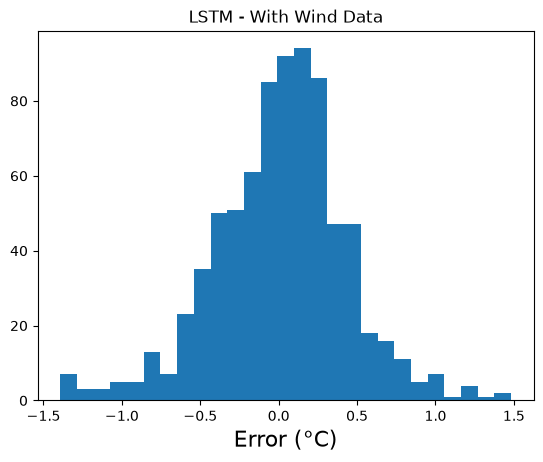

In [45]:
plt.hist(test_x_df.errors, bins='auto')
plt.title('LSTM - With Wind Data')
plt.xlabel('Error (\u00b0C)', fontsize=16)
plt.show()

In [46]:
pd.DataFrame(test_x_df.errors.describe()).T

,count,mean,std,min,25%,50%,75%,max
errors,779.0,0.01378,0.426641,-1.393007,-0.23225,0.033447,0.266595,1.482789


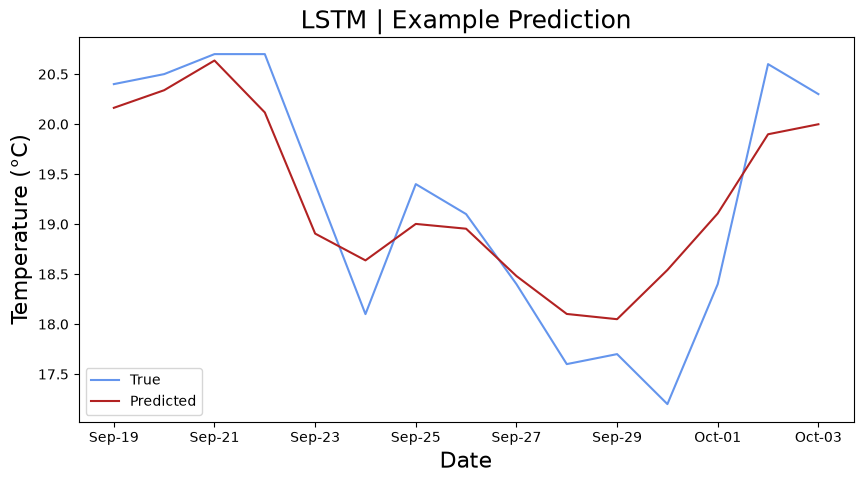

In [ ]:
plot_df = test_x_df[5:20].copy()
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(plot_df.date, plot_df.actual, label='True', color='cornflowerblue')
ax.plot(plot_df.date, plot_df.predicted, label='Predicted', color='firebrick')
ax.set_ylabel('Temperature (\u00b0C)', fontsize=16)
ax.set_xlabel('Date', fontsize=16)
ax.set_title('LSTM | Example Prediction | Wind Data', fontsize=18)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
plt.show()

In [51]:
mse = np.mean([x**2 for x in test_x_df.errors])
rmse = np.sqrt(mse)
r_2 = r2_score(y_seq_test.squeeze(), y_pred)

print(f'RMSE = {round(rmse, 2)}')
print(f'r2 score = {round(r_2, 2)}')

RMSE = 0.43
r2 score = 0.97
